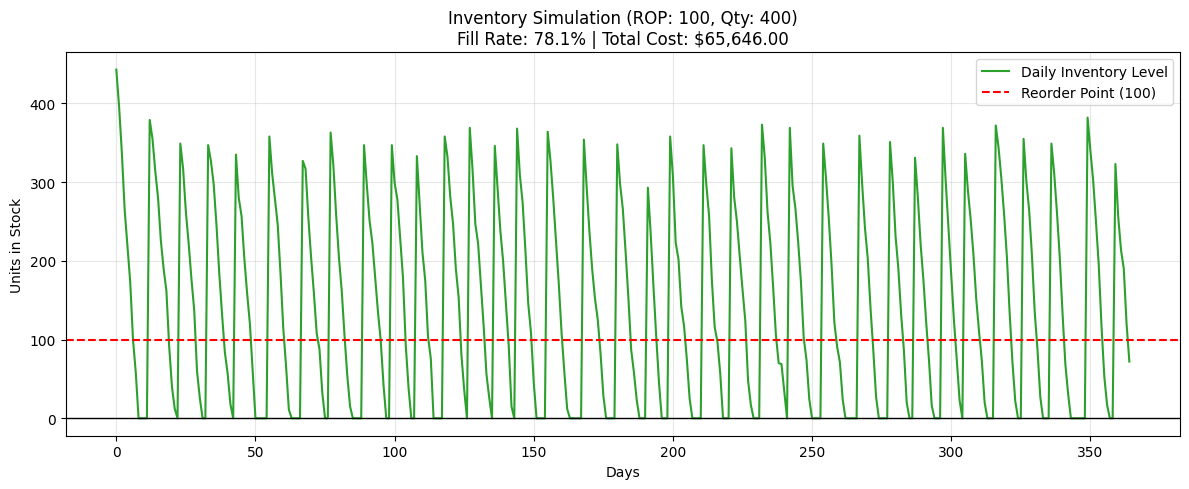

Fill Rate (%)           78.1
Holding Cost ($)     25726.0
Stockout Cost ($)    39920.0
Total Cost ($)       65646.0
dtype: float64


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_inventory_simulation(reorder_point, order_qty, days=365):
    # --- 1. Business Parameters ---
    mean_demand = 50
    std_demand = 15      # Volatility in customer demand
    mean_lead_time = 5   # Days it takes for a supplier to deliver
    std_lead_time = 1.5  # Volatility in supplier delivery
    
    holding_cost_per_unit = 0.50  # Cost to hold 1 unit for 1 day
    stockout_cost_per_unit = 10.0 # Cost of a lost sale
    
    # --- State Variables ---
    current_inventory = order_qty + reorder_point
    inventory_levels = []
    stockout_units_total = 0
    holding_units_total = 0
    
    # Order tracking: dict of {arrival_day: quantity}
    pending_orders = {} 
    
    # --- 2 & 3. The Daily Simulation Loop ---
    for day in range(days):
        # Check if any pending orders arrive today
        if day in pending_orders:
            current_inventory += pending_orders[day]
            del pending_orders[day]
            
        # Generate random demand for the day (can't be negative)
        daily_demand = max(0, int(np.random.normal(mean_demand, std_demand)))
        
        # Fulfill demand
        if current_inventory >= daily_demand:
            current_inventory -= daily_demand
        else:
            # Stockout occurs
            stockout_units = daily_demand - current_inventory
            stockout_units_total += stockout_units
            current_inventory = 0 # Inventory bottoms out at 0
            
        # Track ending inventory for holding costs
        holding_units_total += current_inventory
        inventory_levels.append(current_inventory)
        
        # Trigger new order if we hit the reorder point and nothing is currently on the way
        if current_inventory <= reorder_point and not pending_orders:
            # Generate random lead time
            lead_time = max(1, int(np.random.normal(mean_lead_time, std_lead_time)))
            arrival_day = day + lead_time
            pending_orders[arrival_day] = order_qty

    # --- 4. Calculate KPIs ---
    total_holding_cost = holding_units_total * holding_cost_per_unit
    total_stockout_cost = stockout_units_total * stockout_cost_per_unit
    total_cost = total_holding_cost + total_stockout_cost
    
    total_demand = (mean_demand * days)
    fill_rate = ((total_demand - stockout_units_total) / total_demand) * 100

    # --- 5. Visualization ---
    plt.figure(figsize=(12, 5))
    plt.plot(inventory_levels, label="Daily Inventory Level", color="#2ca02c", linewidth=1.5)
    plt.axhline(y=reorder_point, color='r', linestyle='--', label=f"Reorder Point ({reorder_point})")
    plt.axhline(y=0, color='black', linewidth=1)
    
    plt.title(f"Inventory Simulation (ROP: {reorder_point}, Qty: {order_qty})\nFill Rate: {fill_rate:.1f}% | Total Cost: ${total_cost:,.2f}")
    plt.xlabel("Days")
    plt.ylabel("Units in Stock")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "Fill Rate (%)": round(fill_rate, 1),
        "Holding Cost ($)": total_holding_cost,
        "Stockout Cost ($)": total_stockout_cost,
        "Total Cost ($)": total_cost
    }

# Run a baseline scenario
np.random.seed(42) # Set seed for reproducibility
results = run_inventory_simulation(reorder_point=100, order_qty=400)
print(pd.Series(results))